In [ ]:
import marimo as mo

# Perceptron Classification

*August 4 2026*
*Training Workshop: Introduction to Deep Graph Learning*
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*

Before discussing neural networks, we first introduce the perceptron, a fundamental building block of (deep) neural networks. We consider a perceptron classifier with a logistic activation function, which is the one-dimensional version of the so-called [softmax function](https://en.wikipedia.org/wiki/Softmax_function) that is often used in neural networks. We implement a simple gradient-based learning algorithm and implement the model in a style that mimics the implementation of deep neural networks in `pytorch`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
from scipy.special import expit

plt.style.use('default')
sns.set_style("whitegrid")

To test and illustrate our model, we first generate the same (linearly separable) example data as in notebook 03.

In [ ]:
def response(x, boundary=0.2, prob_1=1):
    """Generate a probabilistic binary response based on a threshold."""
    if x > boundary:
        if np.random.random_sample() < prob_1:
            return 1
        else:
            return 0
    else:
        if np.random.random_sample() < 1-prob_1:
            return 1
        else:
            return 0

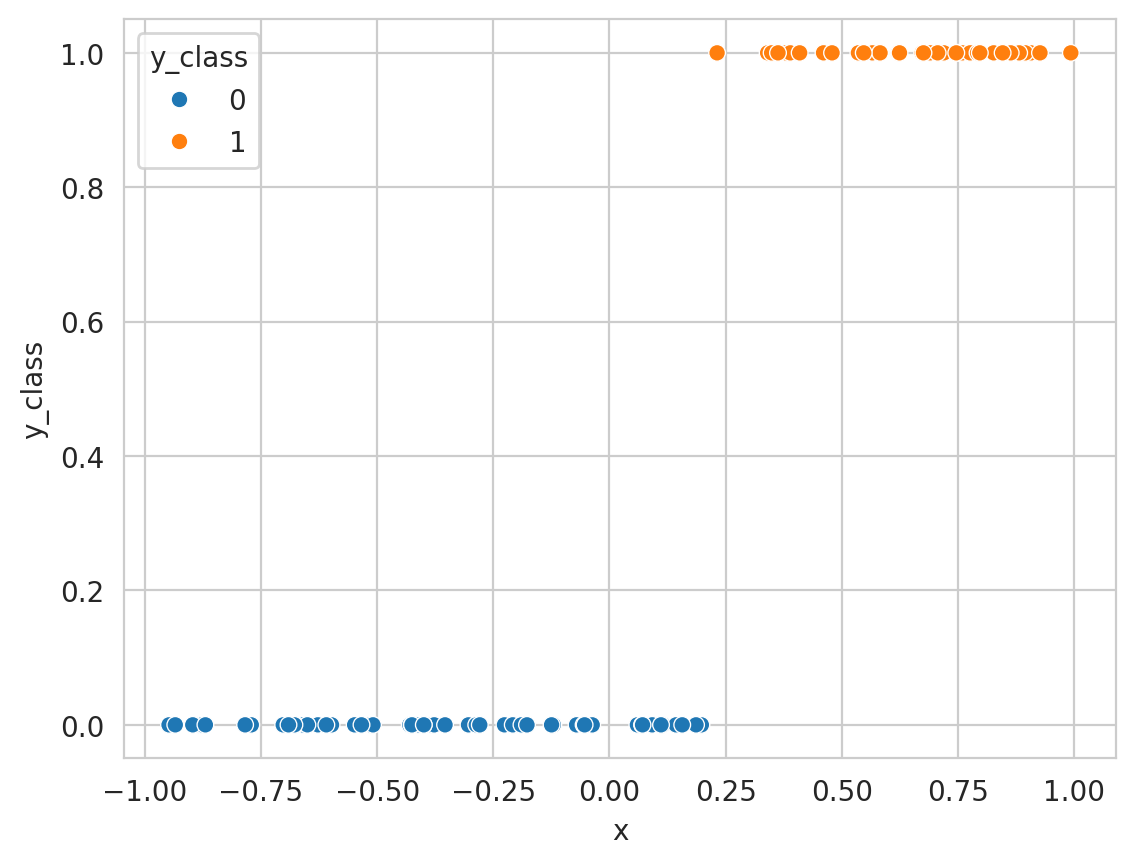

In [ ]:
x = 2 * scipy.stats.uniform.rvs(size=100) - 1
_y = np.array([response(x[i]) for i in range(len(x))])
data = pd.DataFrame({'x': x, 'y_class': _y})
sns.scatterplot(x='x', y='y_class', data=data, hue='y_class')

Referring to the lecture, we can view a logistic regression as special case of a perceptron classifier, where the features represent a (possibly vector-valued) input, and the neuron generates a binary output. This output is computed based on the linear combination of features (with an additional bias/intercept term that determines the "threshold potential"). The "activation function", which we can choose as logistic function, maps the value of the linear function to values in [0,1] that can be interpreted as probability of the positive class.

We can implement this simple model as follows. Here we use the convention of a `pytorch` model, which has a `forward` function that takes the input and generates an output based on the current parameters. This approach will later help us to understand how to use (graph) neural networks based on `pytorch` and `torch-geometric`.

In [ ]:
class Perceptron:
    """A simple logistic regression model."""

    def __init__(self, bias, beta):
        """Initialize the model parameters."""
        self.bias = bias
        self.beta = beta

    def forward(self, x):
        """Compute the output of the model."""
        y = self.bias + np.dot(self.beta, x)
        return expit(y)

Again following the style of optimization algorithms included in `pytorch`, we implement a class `GradientDescentOptimizer`, which can be initialized with different hyperparameters and performs updates of the model parameters. We use the gradients for the beta and bias parameter that we calculaed on slide 9 of the lecture.

In [ ]:
class GradientDescentOptimizer:
    """A simple gradient descent optimizer."""
    
    def __init__(self, model, lr):
        """Initialize the optimizer with learning rate and model."""
        self.lr = lr
        self.model = model

    def step(self, y, y_true, feature):
        """Update the model parameters using a single gradient descent step."""
        self.model.beta = self.model.beta - self.lr * (y-y_true) * y * (1-y) * feature
        self.model.bias = self.model.bias - self.lr * (y-y_true) * y * (1-y)

We now initialize our Perceptron model as well as our optimizer class. Following the nomenclature of neural networks, the optimization is run for a number of so-called **epochs**. In each epoch we use all of our data points to learn the parameters of our perceptron model, i.e. by using multiple epochs we use all data points in our training set more than once.

Each epoch can consist of multiple **iterations**, where each iteration uses a **batch** of data points to update the model parameters. Below, we use a single data point per iteration, which would correspond to a batch size of one.

Using this approach, we can now learn the two parameters of our perceptron model based on our training data. We finally output the parameters, which correspond to the intercept and slope of our logistic regression model. We also plot the evolution of our model error in each epoch, showing that it converges to zero (at least for our simple example of data points that can easily be separated using the right parameters).

In [ ]:
error = np.inf
tol = 0.05
learning_rate = 0.1
epochs = 1000
model = Perceptron(0, 0)
optimizer = GradientDescentOptimizer(model, lr=learning_rate)
errors = []
num_epochs = 0
for i in range(epochs):
    error = 0
    for iteration, row in data.iterrows():
# in each epoch we use all of our training data to update the model parameters once
        _y = model.forward(row['x'])
        loss = (row['y_class'] - _y) ** 2
        error += np.abs(loss)
        optimizer.step(_y, row['y_class'], row['x'])  # in each iteration we use a single data point, i.e. here we have a batch size of one
    errors.append(error)  # and the number of iterations is equal to the number of batches
    num_epochs += 1
    if error <= tol:
        break  # compute output for feature x
plt.plot(range(num_epochs), errors)
print(model.bias, model.beta)  # compute loss  # in each iteration, we update model parameters based on gradient descent

-3.5011864157122767 14.01488113807056


Let us now plot the decisions of our model. Since the output are class probabilities, we need to dichotomize the output based on a threshold of 0.5. This corresponds to a step activation function.

           x  y_class  prediction
0  -0.413703        0           0
1   0.540649        1           1
2   0.460847        1           1
3   0.621325        1           1
4  -0.660367        0           0
..       ...      ...         ...
95 -0.279039        0           0
96 -0.053428        0           0
97  0.993242        1           1
98  0.156723        0           0
99  0.624457        1           1

[100 rows x 3 columns]


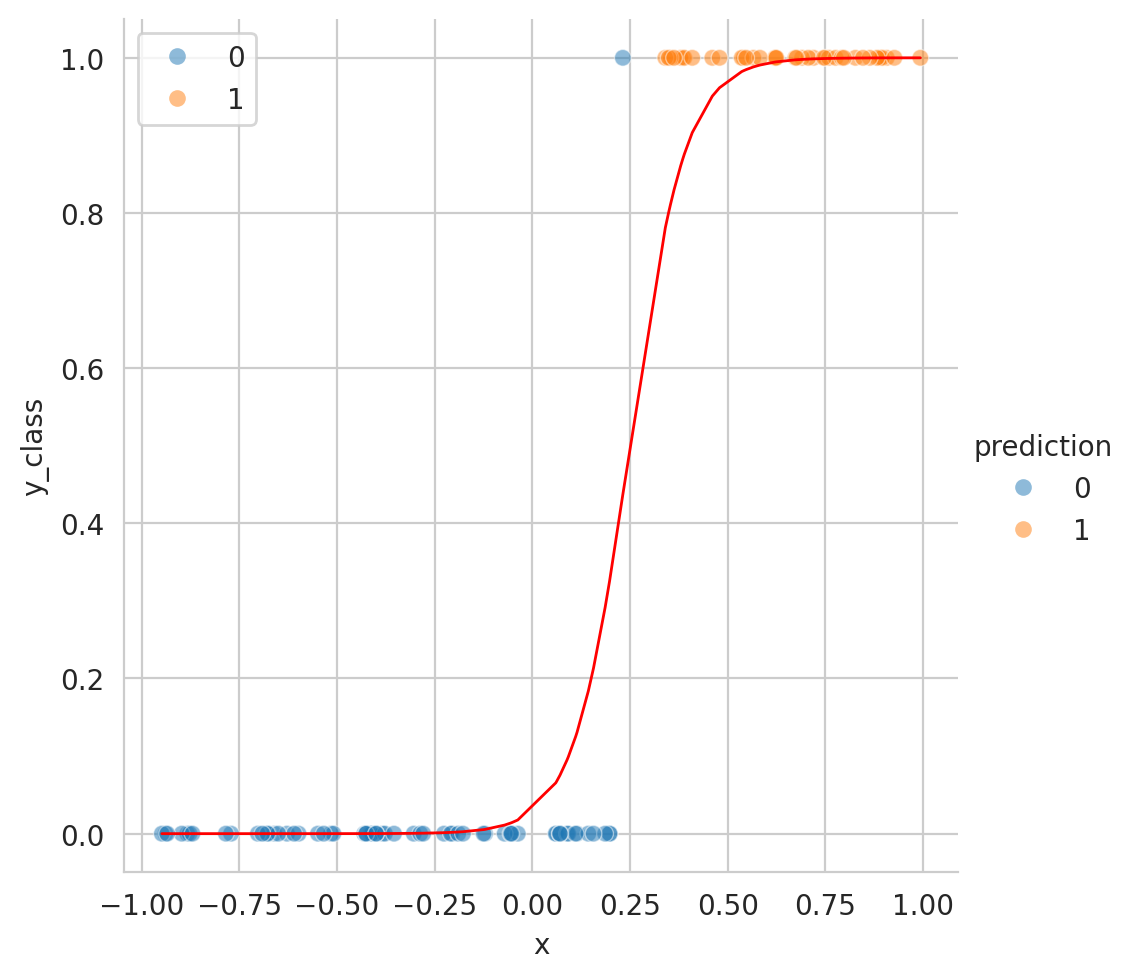

In [ ]:
def decision(output):
    """Dichotomize output based on threshold of 0.5."""
    if output>0.5:
        return 1
    else:
        return 0

xx = data['x']
data['prediction'] = [ decision(model.forward(x)) for x in xx]
print(data)
sns.relplot(x='x', y="y_class", hue='prediction', data=data, alpha=0.5)
sns.lineplot(x=data['x'], y=expit(model.bias + x * model.beta).ravel(), color='red', linewidth=1)

This concludes our implementation of the Perceptron classifier. In the next notebook, we will repeat this implementation based on the popular machine learning package `pytorch`.